In [285]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler , LabelEncoder
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,mean_squared_error,mean_absolute_error,r2_score

In [286]:
df=pd.read_csv("StudentsPerformance.csv")

In [287]:
df.shape

(1000, 8)

In [288]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [289]:
#let create a new feature......
result={}


for i in range(0,1000):
    if df.loc[i,"math score"]<55 or df.loc[i,"reading score"]<55 or df.loc[i,"writing score"]<65 :
        result[i]="Fail"
    else:
        result[i]="Pass"
     

In [290]:
df['result']=pd.Series(result)
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score', 'result'],
      dtype='object')

In [291]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,result
0,female,group B,bachelor's degree,standard,none,72,72,74,Pass
1,female,group C,some college,standard,completed,69,90,88,Pass
2,female,group B,master's degree,standard,none,90,95,93,Pass
3,male,group A,associate's degree,free/reduced,none,47,57,44,Fail
4,male,group C,some college,standard,none,76,78,75,Pass


In [292]:
df["result"].value_counts()

result
Pass    588
Fail    412
Name: count, dtype: int64

In [293]:
df["final_score"] = (df["math score"] +df["reading score"] +df["writing score"]) / 3

In [294]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,result,final_score
0,female,group B,bachelor's degree,standard,none,72,72,74,Pass,72.666667
1,female,group C,some college,standard,completed,69,90,88,Pass,82.333333
2,female,group B,master's degree,standard,none,90,95,93,Pass,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,Fail,49.333333
4,male,group C,some college,standard,none,76,78,75,Pass,76.333333


In [295]:
#let remove some column due to avoid data lackage......

df.drop(columns=["math score","reading score","writing score"],inplace=True)

In [296]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,result,final_score
0,female,group B,bachelor's degree,standard,none,Pass,72.666667
1,female,group C,some college,standard,completed,Pass,82.333333
2,female,group B,master's degree,standard,none,Pass,92.666667
3,male,group A,associate's degree,free/reduced,none,Fail,49.333333
4,male,group C,some college,standard,none,Pass,76.333333


In [297]:
df['lunch'].value_counts()

lunch
standard        645
free/reduced    355
Name: count, dtype: int64

In [298]:
df['parental level of education'].value_counts()

parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

In [299]:
df['gender'].value_counts()

gender
female    518
male      482
Name: count, dtype: int64

In [300]:
df['gender']=df['gender'].map({"male":1,"female":0})
df.rename(columns={"gender":"is_male"},inplace=True)

In [301]:
df.head()

,is_male,race/ethnicity,parental level of education,lunch,test preparation course,result,final_score
0,0,group B,bachelor's degree,standard,none,Pass,72.666667
1,0,group C,some college,standard,completed,Pass,82.333333
2,0,group B,master's degree,standard,none,Pass,92.666667
3,1,group A,associate's degree,free/reduced,none,Fail,49.333333
4,1,group C,some college,standard,none,Pass,76.333333


In [302]:
df["test preparation course"].value_counts()


test preparation course
none         642
completed    358
Name: count, dtype: int64

In [303]:
df.groupby("lunch")["final_score"].mean()

lunch
free/reduced    62.199061
standard        70.837209
Name: final_score, dtype: float64

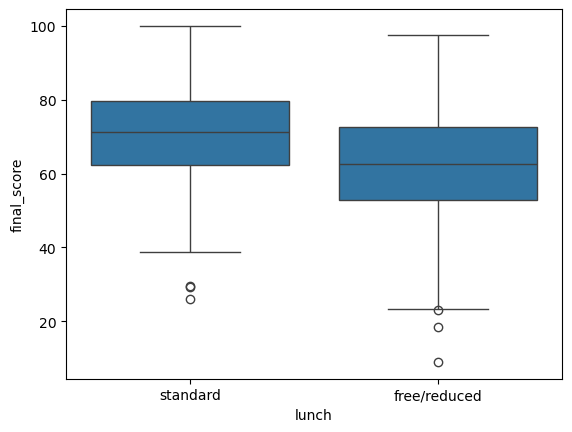

In [304]:
sns.boxplot(
    x="lunch",
    y="final_score",
    data=df
)
plt.show()

In [305]:
df['lunch']=df['lunch'].map({"free/reduced":0,"standard":1})

In [306]:
corr=df["is_male"].corr(df["final_score"])
corr

np.float64(-0.1308612298848538)

In [307]:
df.groupby('is_male')['final_score'].mean()

is_male
0    69.569498
1    65.837483
Name: final_score, dtype: float64

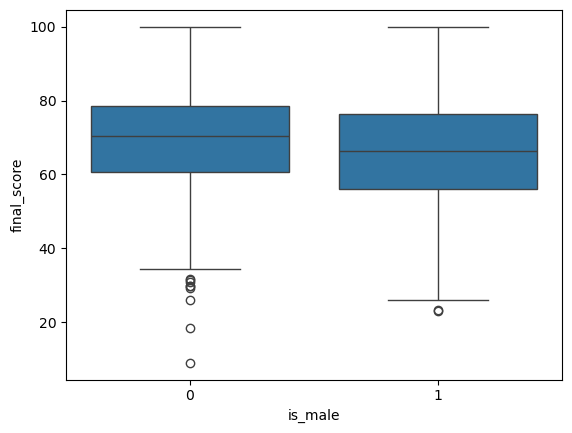

In [308]:
sns.boxplot(x="is_male", y="final_score", data=df)
plt.show()

In [309]:
df["test preparation course"].unique()

array(['none', 'completed'], dtype=object)

In [310]:
df["test preparation course"].value_counts()

test preparation course
none         642
completed    358
Name: count, dtype: int64

In [311]:
df["test preparation course"]=df["test preparation course"].map({"none":0,"completed":1})

In [312]:
df['test preparation course'].value_counts()


test preparation course
0    642
1    358
Name: count, dtype: int64

In [313]:
df.rename(columns={"test preparation course":"is_test_preparation_course_complete"},inplace=True)

In [314]:
df['is_test_preparation_course_complete'].value_counts()

is_test_preparation_course_complete
0    642
1    358
Name: count, dtype: int64

In [315]:
df.dtypes

is_male                                  int64
race/ethnicity                          object
parental level of education             object
lunch                                    int64
is_test_preparation_course_complete      int64
result                                  object
final_score                            float64
dtype: object

In [316]:
df.head()

,is_male,race/ethnicity,parental level of education,lunch,is_test_preparation_course_complete,result,final_score
0,0,group B,bachelor's degree,1,0,Pass,72.666667
1,0,group C,some college,1,1,Pass,82.333333
2,0,group B,master's degree,1,0,Pass,92.666667
3,1,group A,associate's degree,0,0,Fail,49.333333
4,1,group C,some college,1,0,Pass,76.333333


In [317]:
df=pd.get_dummies(df,columns=["race/ethnicity","parental level of education",],dtype=int)

In [318]:
df.columns

Index(['is_male', 'lunch', 'is_test_preparation_course_complete', 'result',
       'final_score', 'race/ethnicity_group A', 'race/ethnicity_group B',
       'race/ethnicity_group C', 'race/ethnicity_group D',
       'race/ethnicity_group E',
       'parental level of education_associate's degree',
       'parental level of education_bachelor's degree',
       'parental level of education_high school',
       'parental level of education_master's degree',
       'parental level of education_some college',
       'parental level of education_some high school'],
      dtype='object')

In [319]:
df.dtypes

is_male                                             int64
lunch                                               int64
is_test_preparation_course_complete                 int64
result                                             object
final_score                                       float64
race/ethnicity_group A                              int64
race/ethnicity_group B                              int64
race/ethnicity_group C                              int64
race/ethnicity_group D                              int64
race/ethnicity_group E                              int64
parental level of education_associate's degree      int64
parental level of education_bachelor's degree       int64
parental level of education_high school             int64
parental level of education_master's degree         int64
parental level of education_some college            int64
parental level of education_some high school        int64
dtype: object

In [320]:
df.isnull().sum()

is_male                                           0
lunch                                             0
is_test_preparation_course_complete               0
result                                            0
final_score                                       0
race/ethnicity_group A                            0
race/ethnicity_group B                            0
race/ethnicity_group C                            0
race/ethnicity_group D                            0
race/ethnicity_group E                            0
parental level of education_associate's degree    0
parental level of education_bachelor's degree     0
parental level of education_high school           0
parental level of education_master's degree       0
parental level of education_some college          0
parental level of education_some high school      0
dtype: int64

In [321]:
df['result']=df['result'].map({"Pass":1,"Fail":0})
df['result'].value_counts()

result
1    588
0    412
Name: count, dtype: int64

In [322]:
df.dtypes

is_male                                             int64
lunch                                               int64
is_test_preparation_course_complete                 int64
result                                              int64
final_score                                       float64
race/ethnicity_group A                              int64
race/ethnicity_group B                              int64
race/ethnicity_group C                              int64
race/ethnicity_group D                              int64
race/ethnicity_group E                              int64
parental level of education_associate's degree      int64
parental level of education_bachelor's degree       int64
parental level of education_high school             int64
parental level of education_master's degree         int64
parental level of education_some college            int64
parental level of education_some high school        int64
dtype: object

In [323]:
df.head()


,is_male,lunch,is_test_preparation_course_complete,result,final_score,race/ethnicity_group A,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_associate's degree,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school
0,0,1,0,1,72.666667,0,1,0,0,0,0,1,0,0,0,0
1,0,1,1,1,82.333333,0,0,1,0,0,0,0,0,0,1,0
2,0,1,0,1,92.666667,0,1,0,0,0,0,0,0,1,0,0
3,1,0,0,0,49.333333,1,0,0,0,0,1,0,0,0,0,0
4,1,1,0,1,76.333333,0,0,1,0,0,0,0,0,0,1,0


In [324]:
X_r=df.drop(columns=["result","final_score"])
y_r=df["final_score"]

In [325]:
X_c=df.drop(columns=["result","final_score"])
y_c=df["result"]

In [326]:
X_trainr,X_testr,y_trainr,y_testr=train_test_split(X_r,y_r,test_size=0.2,random_state=42)

from sklearn.linear_model import LinearRegression

m1=LinearRegression()

m1.fit(X_trainr,y_trainr)

y_pred_r=m1.predict(X_testr)

print("r2_score : ",r2_score(y_testr,y_pred_r))

print("mean absolute error : ",mean_absolute_error(y_testr,y_pred_r))

print("mean aquared error : ",mean_squared_error(y_testr,y_pred_r))

r2_score :  0.1621718576315524
mean absolute error :  10.490182374209294
mean aquared error :  179.60234233623535


In [327]:
X_trainc,X_testc,y_trainc,y_testc=train_test_split(X_c,y_c,test_size=0.2,random_state=42)

from sklearn.ensemble import RandomForestClassifier

m2=RandomForestClassifier(n_estimators=100,max_depth=5,class_weight="balanced",random_state=42)

m2.fit(X_trainc,y_trainc)

y_pred_c=m2.predict(X_testc)

print("accuracy score :- ",accuracy_score(y_testc,y_pred_c))
print()
print()
print(" Classification Report :-\n ",classification_report(y_testc,y_pred_c))

accuracy score :-  0.69


 Classification Report :-
                precision    recall  f1-score   support

           0       0.64      0.70      0.67        90
           1       0.74      0.68      0.71       110

    accuracy                           0.69       200
   macro avg       0.69      0.69      0.69       200
weighted avg       0.69      0.69      0.69       200



In [328]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
)

rf.fit(X_trainr, y_trainr)

pred = rf.predict(X_testr)

print(r2_score(y_testr, pred))

-0.02770044088849888


In [329]:
'''here we can show that 
    Random Forest Classifier achieved an accuracy of 69%. 
    The model showed balanced performance across both classes with F1-scores of 0.67 and 0.71, 
    indicating reasonable predictive capability for student pass/fail classification.

    Regression models were unable to accurately predict final scores due to limited predictive features. 
    The best R² score obtained was approximately 0.16.'''

'here we can show that \n    Random Forest Classifier achieved an accuracy of 69%. \n    The model showed balanced performance across both classes with F1-scores of 0.67 and 0.71, \n    indicating reasonable predictive capability for student pass/fail classification.\n\n    Regression models were unable to accurately predict final scores due to limited predictive features. \n    The best R² score obtained was approximately 0.16.'